# **Inteligencia Artificial y Aprendizaje Automático**
## **Maestría en Inteligencia Artificial Aplicada**
### **Dr Luis Eduardo Falcón Morales**
### **Tecnológico de Monterrey**
**Actividad Curvas ROC y PR**


# **Itroducción**

La actividad se basa en los datos conocidos como "oil-spill" (derrame de petróleo).

El archivo de los datos está en Canvas y se llama "oil-spill.csv".


En la siguiente liga se encuentra la liga del artículo relacionado a dicha base de datos. Los datos incluyen 50 columnas y 937 registros. Las primeras 49 columnas son métricas obtenidas de imágenes satelitales del océano, en algunas de las cuales se tiene petróleo que fue derramado por alguna fuente desconocida. En el artículo se describe a detalle la manera en que se obtuvieron dichas columnas. Para la actividad es suficiente considerarlas como de valor numérico. La última columna es de valor 1 (hay derrame en esa sección de la imagen) o 0 (no hay derrame en esa sección de la imagen).

https://webdocs.cs.ualberta.ca/~holte/Publications/oilspill.pdf

En la siguiente liga puedes encontrar información de varias de las métricas que estaremos utilizando:

https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter

La media geométrica se puede obtener combinando las métricas anteriores, pero para fines prácticos usaremos la de la librería llamada "imbalanced-learn":

https://glemaitre.github.io/imbalanced-learn/generated/imblearn.metrics.geometric_mean_score.html

In [ ]:
# Incluye todas las librerías que consideres adecuadas:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas import read_csv
from sklearn.model_selection import train_test_split

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from imblearn.metrics import geometric_mean_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from numpy import mean
from numpy import std
import os

from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, roc_curve, precision_recall_curve, roc_auc_score, average_precision_score
from sklearn.metrics import confusion_matrix

Para fines de la actividad procesaremos los datos de manera estándar para concentrarnos en los temas de la actividad.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/AI & ML/oil_spill.csv'
df = read_csv(path, header=None)   # no tienen nombre las columnas

print('Timensión del DataFrame',df.shape)

# eliminamos las siguientes columnas:
df.drop(22, axis=1, inplace=True)    # Esta columna tiene un solo valor constante.
df.drop(0, axis=1, inplace=True)     # Esta columna contiene información de secciones (batches) de las imágenes, que no la requerimos.

df.columns = [i for i in range(df.shape[1])]   # Renombramos las columnas para que sean enteros consecutivos.

# Particionamos los datos de entrada (X) y de salida (y):
X,y = df.iloc[:,:-1], df.iloc[:,-1]

Xtv, Xtest, ytv, ytest = train_test_split(X, y, test_size=0.12, stratify=y, shuffle=True, random_state=0)
Xtrain, Xval, ytrain, yval = train_test_split(Xtv, ytv, test_size=0.2, shuffle=True, random_state=5)
print('\nPartición:')
print('Train: Conteo clase positiva=%d, Porcentaje=%.2f%%' % (ytrain.sum(), 100*(ytrain.sum() / len(ytrain))))
print('Val: Conteo clase positiva=%d, Porcentaje=%.2f%%' % (yval.sum(), 100*(yval.sum() / len(yval))))
print('Test: Conteo clase positiva=%d, Porcentaje=%.2f%%' % (ytest.sum(), 100*(ytest.sum() / len(ytest))))

Timensión del DataFrame (937, 50)

Partición:
Train: Conteo clase positiva=29, Porcentaje=4.40%
Val: Conteo clase positiva=7, Porcentaje=4.24%
Test: Conteo clase positiva=5, Porcentaje=4.42%


Breve descripción numérica y gráfica del conjunto de entrenamiento:

In [ ]:
Xtrain.describe().T

,count,mean,std,min,25%,50%,75%,max
0,659.0,344.153263,1.880555e+03,10.00,22.000,65.00,134.500,28526.00
1,659.0,709.286161,5.993162e+02,1.95,97.475,727.45,1242.135,1893.08
2,659.0,867.791608,5.145066e+02,1.00,445.065,791.35,1243.220,2674.16
3,659.0,85.078907,4.573682e+01,0.00,55.000,74.00,119.000,180.00
4,659.0,824339.418816,4.131627e+06,70312.00,127500.000,187500.00,348750.000,71315000.00
5,659.0,42.966449,1.259403e+01,21.24,33.430,39.64,51.975,82.64
6,659.0,9.162307,3.587007e+00,0.83,6.920,8.22,10.755,24.28
7,659.0,4119.098634,8.899523e+03,667.00,1404.750,2167.00,3600.000,160740.00
8,659.0,0.222898,8.984421e-02,0.02,0.170,0.21,0.260,0.74
9,659.0,110.288771,6.272348e+01,47.00,82.950,99.80,115.700,901.70


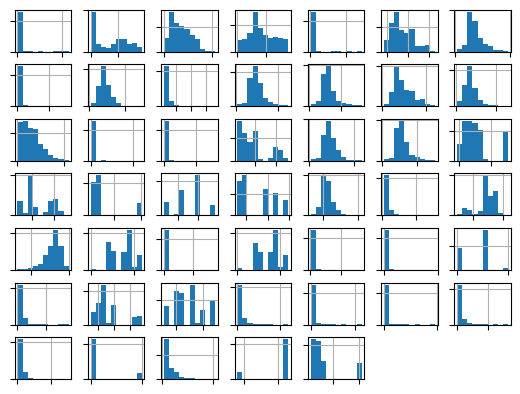

In [ ]:
ax = Xtrain.hist()  # Histogramas:
# Quitemos toda la información del gráfico para visualizarlo de manera sencilla:
for axis in ax.flatten():
  axis.set_title('')
  axis.set_xticklabels([])
  axis.set_yticklabels([])
plt.show()

In [ ]:
Xtrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 659 entries, 770 to 460
Data columns (total 47 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       659 non-null    int64  
 1   1       659 non-null    float64
 2   2       659 non-null    float64
 3   3       659 non-null    int64  
 4   4       659 non-null    float64
 5   5       659 non-null    float64
 6   6       659 non-null    float64
 7   7       659 non-null    float64
 8   8       659 non-null    float64
 9   9       659 non-null    float64
 10  10      659 non-null    float64
 11  11      659 non-null    float64
 12  12      659 non-null    float64
 13  13      659 non-null    float64
 14  14      659 non-null    float64
 15  15      659 non-null    float64
 16  16      659 non-null    float64
 17  17      659 non-null    float64
 18  18      659 non-null    float64
 19  19      659 non-null    float64
 20  20      659 non-null    float64
 21  21      659 non-null    float64
 22  22   

In [ ]:
# Código-1:
# Aplicamos la función Dummy:

def evaluate_model(X, y, model):
  cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
  metric = make_scorer(geometric_mean_score)
  scores = cross_val_score(model, X, y, scoring=metric, cv=cv, n_jobs=-1)
  return scores


modeloD = DummyClassifier(strategy='uniform')
scores = evaluate_model(X, y, modeloD)

print('Métrica G-mean - Media Geométrica: %.3f (%.3f)' % (mean(scores), std(scores)))

Métrica G-mean - Media Geométrica: 0.481 (0.089)


# **Ejercicio-1**

### **Explica lo que hace cada línea de código de la celda anterior llamada "Código-1", así como lo que significa el valor que se obtiene en su salida:**

**+++++++++++ Inicia sección para agregar texto ++++++++++++++++**



1.   se define una función para evaluar el modelo que requiere 3 variables (variables de entrada, variable de salida, y el modelo).
2.   se le asigna a la variables CV las particiones para el modelo, se parte en 10 fracciones, repetirá el ejercicio 3 veces y se le asigna una semilla para siempre tener consistencia en los resultados.
3.   la variable metric reliza el cálculo basado en la media goemétrica, entiendo que aqui es sólo como instancear.
4.   La variable scores, ejecuta la validación cruzada, sus parámetros indican primero el modelo que se va a correr (logística, ridge, lasso, elasticnet, knn), las variables X, y son las varaibles de entrda y salida respectivamente. el parámetro scoring, será el eque ejecuta la media geométrica, cv son las veces que se ejecutará el aprendizaje, 30 (n_splits * n_repeats). Por último n_jobs indica la cantidad de procesos que se pueden ejecutar en paralelo, al colocarlo en -1 se vana aocupar todos los núcleos diponibles del procesador.
5.   return, es sólo el resultadod e la función, el cual es scores, y termian la función..
6.   La variabel modelo, almacena una línea base con la función DUMMYCLASSIFIER, esta función lo que hace es predecir los posibles resultados de Y; esto con el objetivo de poder comparar los resultados de los diferentes predictores. El parámetro STRATEGY=UNIFORM lo que hace es dividir las diferentes categorías de Y (ej. 'SI', 'NO', 'Talvez') de tal manera que todas tengan la misma probabildad (33%) de salir en el resultado.
7.   la variable scores ejecuta el código de la función y se le pasan los parámetros requeridos.
8.   El print lo que hace es msotrar en pantalla los resultados de la media geométrica y el nivel de asertividad de la validación cruzada.
9.   Significado del valor de salida: La información que obtenemos es que la media de nuestros datos es del 51 y que el modelo es correcto en un 15%.




**+++++++++++ Termina sección para agregar texto ++++++++++++++**

Para fines de esta actividad definimos las siguientes transformaciones del preprocesamiento de los datos:

In [ ]:
# Transforamaciones numéricas:

numericas_pipeline = Pipeline(steps = [('impMediana', SimpleImputer(strategy='mean')),
                                       ('std_transformer', StandardScaler())])
numericas_pipeline_nombres = Xtrain.columns

columnasTransformer = ColumnTransformer(transformers = [('num', numericas_pipeline, numericas_pipeline_nombres)],
                                        remainder='passthrough')

In [ ]:
mi_metrica = make_scorer(geometric_mean_score)  # definimos la métrica G-mean

Resultados de Validación:
LR
Exactitud: >> 0.951 (0.015)
G-mean: >> 0.741 (0.079)

LASSO
Exactitud: >> 0.968 (0.009)
G-mean: >> 0.689 (0.104)

RIDGE
Exactitud: >> 0.969 (0.011)
G-mean: >> 0.725 (0.108)

EN
Exactitud: >> 0.968 (0.010)
G-mean: >> 0.694 (0.112)

kNN
Exactitud: >> 0.966 (0.005)
G-mean: >> 0.464 (0.204)



<ipython-input-66-0db74e03d2d4>:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(resultados1, labels=nombres,  showmeans=True)


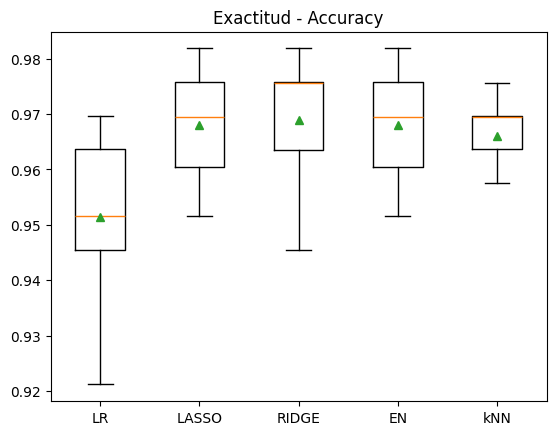

<ipython-input-66-0db74e03d2d4>:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(resultados2, labels=nombres,  showmeans=True)


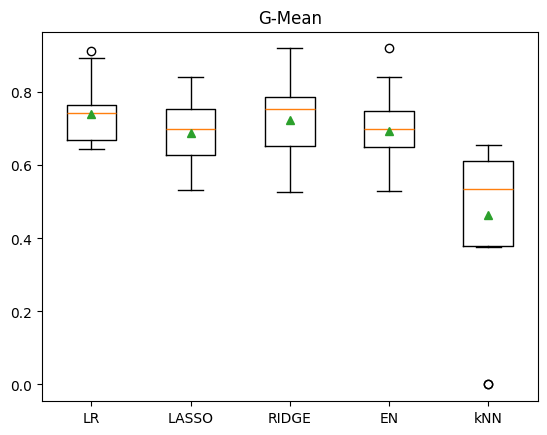

In [ ]:
# Código-2:
# ACCURACY & G-mean

def mis_modelos1():
  modelos, nombres = list(), list()

  modelos.append(LogisticRegression(penalty=None,
                                    max_iter=2000,
                                    random_state=1))
  nombres.append('LR')


  modelos.append(LogisticRegression(penalty='l1',
                                    solver='liblinear',
                                    max_iter=2000,
                                    random_state=1))
  nombres.append('LASSO')


  modelos.append(LogisticRegression(penalty='l2',
                                    max_iter=2000,
                                    random_state=1))
  nombres.append('RIDGE')

  modelos.append(LogisticRegression(penalty='elasticnet',
                                    l1_ratio=0.5,
                                    solver='saga',
                                    max_iter=5000,
                                    random_state=1))
  nombres.append('EN')

  modelos.append(KNeighborsClassifier(n_neighbors=5))
  nombres.append('kNN')

  return modelos, nombres

# +++++++++++++++++++++++++++++++


modelos, nombres = mis_modelos1()
resultados1, resultados2 = list(), list()
print('Resultados de Validación:')

for i in range(len(modelos)):

  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])
  cv1 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)
  scores = cross_validate(pipeline,
                          Xtv,
                          np.ravel(ytv),
                          scoring={'exactitud':'accuracy', 'm_geo':mi_metrica},
                          cv=cv1)

  resultados1.append(scores['test_exactitud'])
  resultados2.append(scores['test_m_geo'])

  print(nombres[i])
  print('Exactitud: >> %.3f (%.3f)' % (np.nanmean(scores['test_exactitud']), np.nanstd(scores['test_exactitud'])))
  print('G-mean: >> %.3f (%.3f)' % (np.nanmean(scores['test_m_geo']), np.nanstd(scores['test_m_geo'])))
  print()

plt.boxplot(resultados1, labels=nombres,  showmeans=True)
plt.title("Exactitud - Accuracy")
plt.show()

plt.boxplot(resultados2, labels=nombres,  showmeans=True)
plt.title("G-Mean")
plt.show()


# **Ejercicio-2**

### **Explica por qué la salida y gráficos anteriores nos ayudan a respaldar la decisión de usar la métrica G-mean, en lugar de la exactitud (accuracy) en este problema:**

**+++++++++++ Inicia sección para agregar texto ++++++++++++++++**



Los gráficos de Accuracy, muestran que el modelo, aparentemente, "aprende" de manera correcta; sin mebago, esto no es así. Lo anterior debido a que las clases están desbalanceadas, las implicaciones de lo anterior es que los FN y FP están siendo ignorados por el modelo. La clase mayoritaria, siendo los VN, son enormes si los comparas con los VP. Esto afecta al modelo, debido a que sólo aprende lo que está clasficiado como negativo; sin poder distinguir los correctos.

Con relación a las medias geométricas, puedo ovbservar que el rendimiento del modelo es mejor con Lasso y Ridge debido a que no muestran outliers, a diferencia de los otros modelos. Sin embargo, tampoco puedo considerar que los modelos sean correctos, debido a los puntos mencionados en el párrafo anterior.

Con relación a escenario que plantea el ejercicio, esto implica que el modelo no podría detectar un derrame de petróleo, pues todo lo pasaría como que no hay derrame; esto tomando en cuenta que 0 es no hay derrame y 1 si hay derrame.



**+++++++++++ Termina sección para agregar texto ++++++++++++++**

# **Ejercicio-3**

### **Utilizando en adelante solamente la métrica G-mean y de manera análoga al código de la celda llamada "Código-2" anterior, define una función llamada "mis_modelos2()" y utilízala para definir los mismos modelos de regresión logística, pero incluyendo el argumento class_weight='balanced'. Los demás hiperparámetros los puedes variar si así lo consideras adecuado. Incluye kNN, aunque no tiene argumento para balanceo de las clases de salida.**

Resultados de Validación:
LR
G-mean: >> 0.682 (0.205)
LASSO
G-mean: >> 0.836 (0.133)
RIDGE
G-mean: >> 0.838 (0.132)
EN
G-mean: >> 0.837 (0.132)
kNN
G-mean: >> 0.466 (0.215)


<ipython-input-72-af2d0f57b109>:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(resultados3, labels=nombres2,  showmeans=True)   # gráficos de caja para una comparación visual de los resultados.


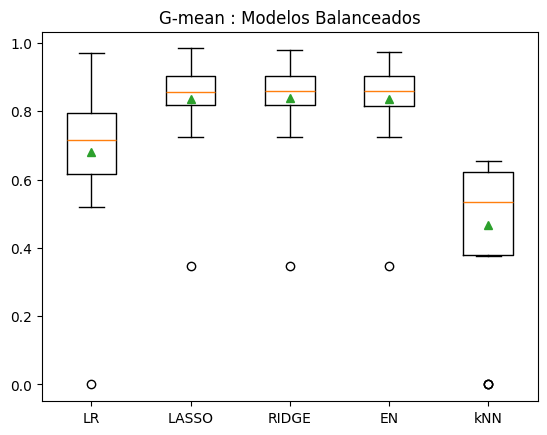

In [ ]:
#  Casos balancedos con hiperparámetro de Regresión Logística:

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++

def mis_modelos2():

  modelos2, nombres2 = list(), list()

  modelos2.append(LogisticRegression(penalty=None,
                                    max_iter=2000,
                                    random_state=1,
                                    class_weight='balanced',
                                    warm_start=True))
  nombres2.append('LR')


  modelos2.append(LogisticRegression(penalty='l1',
                                    solver='liblinear',
                                    max_iter=2000,
                                    random_state=1,
                                    class_weight='balanced',
                                    warm_start=True))
  nombres2.append('LASSO')


  modelos2.append(LogisticRegression(penalty='l2',
                                    max_iter=2000,
                                    random_state=1,
                                    class_weight='balanced',
                                    warm_start=True))
  nombres2.append('RIDGE')

  modelos2.append(LogisticRegression(penalty='elasticnet',
                                    l1_ratio=0.5,
                                    solver='saga',
                                    max_iter=5000,
                                    random_state=1,
                                    class_weight='balanced',
                                    warm_start=True))
  nombres2.append('EN')

  modelos2.append(KNeighborsClassifier(n_neighbors=5))
  nombres2.append('kNN')

  return modelos2, nombres2

# +++++++++++++++++++++++++++++++


modelos2, nombres2 = mis_modelos2()
resultados3 = list()
print('Resultados de Validación:')

for i in range(len(modelos2)):

  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos2[i])])
  cv2 = RepeatedStratifiedKFold(n_splits=5, n_repeats=4, random_state=7)
  scores = cross_validate(pipeline,
                          Xtv,
                          np.ravel(ytv),
                          scoring={'m_geo':mi_metrica},
                          cv=cv2)

  resultados3.append(scores['test_m_geo'])
  print(nombres2[i])
  print('G-mean: >> %.3f (%.3f)' % (np.nanmean(scores['test_m_geo']), np.nanstd(scores['test_m_geo'])))
# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++


plt.boxplot(resultados3, labels=nombres2,  showmeans=True)   # gráficos de caja para una comparación visual de los resultados.
plt.title("G-mean : Modelos Balanceados")
plt.show()

# **Ejercicio-4**

### **4a) Selecciona el que consideres sea el mejor modelo encontrado hasta ahora y utilízalo para obtener los gráficos curva-ROC y curva-PR, así como los valores de sus áreas bajo la curva. Sigue utilizando los conjuntos de entrenamiento y validación.**



In [ ]:
# **+++++++++++ Inicia sección para agregar código ++++++++++++++++**
# NOTA: puedes agregar todas las celdas que consideres adecuado.

#concatena los conjuntos
X2=pd.concat([Xtrain,Xval])
y2=pd.concat([ytrain,yval])

# Ridge - Regresión Logística con regularización L2:
mejor_modelo = LogisticRegression(penalty='l2',
                                    max_iter=5000,
                                    random_state=1,
                                    class_weight='balanced',
                                    warm_start=True,
                                    solver='saga')

pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',mejor_modelo)])
cv3 = RepeatedStratifiedKFold(n_splits=8, n_repeats=4, random_state=7)
scores2 = cross_validate(pipeline,
                        X2,
                        np.ravel(y2),
                        scoring={'m_geo':mi_metrica},
                        cv=cv3,
                        return_train_score=True,
                        n_jobs=-1)
print('G-mean: >> %.3f (%.3f)' % (np.nanmean(scores2['test_m_geo']), np.nanstd(scores2['test_m_geo'])))



# **+++++++++++ Termina sección para agregar código ++++++++++++++**

G-mean: >> 0.862 (0.094)


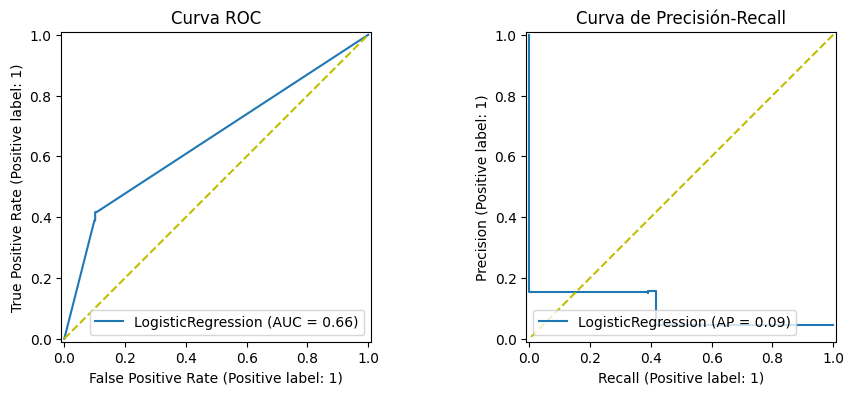

In [ ]:
pipeline.fit(X2, np.ravel(y2))


fig, axes = plt.subplots(1, 2, figsize=(10,15))
plt.subplots_adjust(wspace=0.5, hspace=0.5)
axes = axes.ravel()

# Curva ROC
RocCurveDisplay.from_estimator(mejor_modelo, X2, y2, ax=axes[0]) #acuérdate con el ax=axes[N] se le indica que ahí pones el gráfico
axes[0].plot([0, 1], [0, 1], 'y--')
axes[0].set_title('Curva ROC')



# Curva de Precisión-Recall
PrecisionRecallDisplay.from_estimator(mejor_modelo, X2, y2, ax=axes[1])
axes[1].plot([1,0], [1,0], 'y--')
axes[1].set_title('Curva de Precisión-Recall')

# Mostrar gráficos
plt.show()

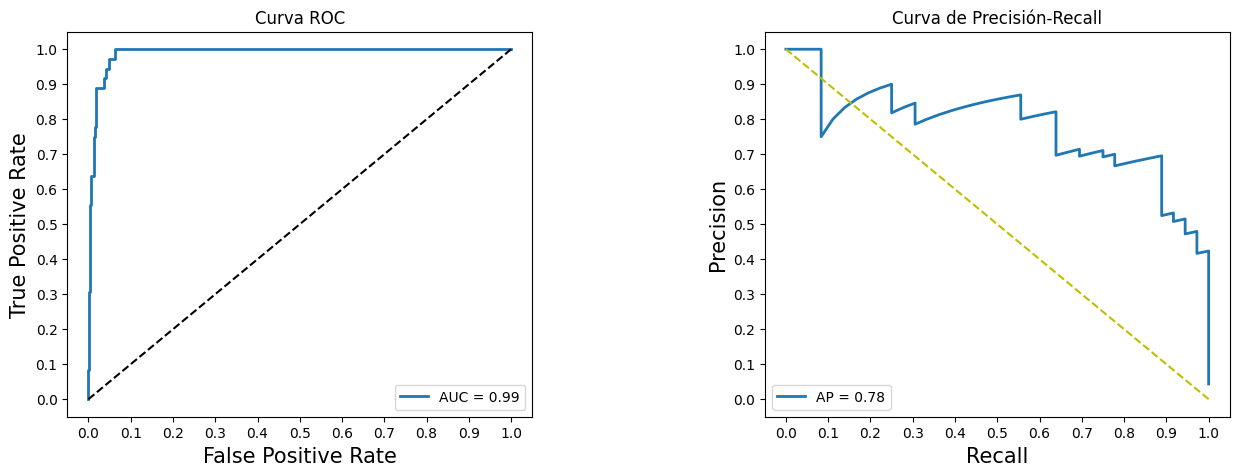

In [ ]:
pipeline.fit(X2, np.ravel(y2)) # fit the pipeline to the training data
y_pred_proba = pipeline.predict_proba(X2)[:, 1] #get predicted probabilities for class 1

fig, axes = plt.subplots(1, 2, figsize=(15,5))
plt.subplots_adjust(wspace=0.5, hspace=0.5)
axes = axes.ravel()

# Curva ROC y AUC
FPR, TPR, _ = roc_curve(y2, y_pred_proba)  # Usa las probabilidades predichas
roc_auc = roc_auc_score(y2, y_pred_proba)
axes[0].plot(FPR, TPR, linewidth=2, label='AUC = {:.2f}'.format(roc_auc))
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlabel("False Positive Rate", fontsize=15)
axes[0].set_ylabel("True Positive Rate", fontsize=15)
axes[0].set_xticks(np.linspace(0, 1, 11))
axes[0].set_yticks(np.linspace(0, 1, 11))
axes[0].set_title('Curva ROC')
axes[0].legend(loc="lower right")

# Curva de Precisión-Recall y AUC (Average Precision)
precision, recall, _ = precision_recall_curve(y2, y_pred_proba)
average_precision = average_precision_score(y2, y_pred_proba)
axes[1].plot(recall, precision, linewidth=2, label='AP = {:.2f}'.format(average_precision))
axes[1].plot([0, 1], [1, 0], 'y--')
axes[1].set_xlabel("Recall", fontsize=15)
axes[1].set_ylabel("Precision", fontsize=15)
axes[1].set_xticks(np.linspace(0, 1, 11))
axes[1].set_yticks(np.linspace(0, 1, 11))
axes[1].set_title('Curva de Precisión-Recall')
axes[1].legend(loc="lower left")

# Mostrar gráficos
plt.show()

In [ ]:
pipeline.fit(X2, np.ravel(y2))
pred_bin=mejor_modelo.predict(X2)
cm= confusion_matrix(y2, pred_bin)
print(cm)

[[717  71]
 [ 24  12]]


### **4b) Incluye tus conclusiones de los gráficos obtenidos en el inciso anterior.**

**+++++++++++ Inicia sección para agregar texto ++++++++++++++++**



Los primeros ROC y PR los hice guiándome bajo los videos del TEC. Mis observaciones son:

1. El umbral de ROC esta marcado en un rango entre los 0.43 y 0.45. Esto implica que mi modelo está siendo subentrenado; pues la mayoría de los puntos estan dentr de la categoría de VN, lo cual implica que es incapaz de detectar un derrame de petróleo.
2. El indicador del AUC está marcado dentro del 0.66, lo cual tampoco sería ccorrecto para un modelo, ya que no cumple con el estándar mínimo del 0.70.
3. La curva PR muestra que los FN son muy pequeños, por lo que el modelo confirmaria estar subentrenado.
4. EL AP (AUC de PR) es muy pequeño, concuerda con lo dicho anteriormente.

En los segundos gráficos, obtenidos de una páginade internet (https://interactivechaos.com/es/manual/tutorial-de-machine-learning/la-funcion-roccurve) observo que la historia es completamente distinta. Pues de acuerdo con las gráficas las clases si están bien balanceadas, el modelo funciona, y no da señales de estar sobre entrenado. Puedo ver que el umbral para la curva ROC se aumentó hasta en un 0.9, por lo tanto la detección de un derrame de petróleo sería correcta. Igualmente la curva PR da soporte al ROC, por lo tanto la precisión del modelo es coherente.


**+++++++++++ Termina sección para agregar texto ++++++++++++++**

# **Ejercicio-5**

### **Utiliza el conjunto de prueba (test) para evaluar el mejor modelo obtenido.**

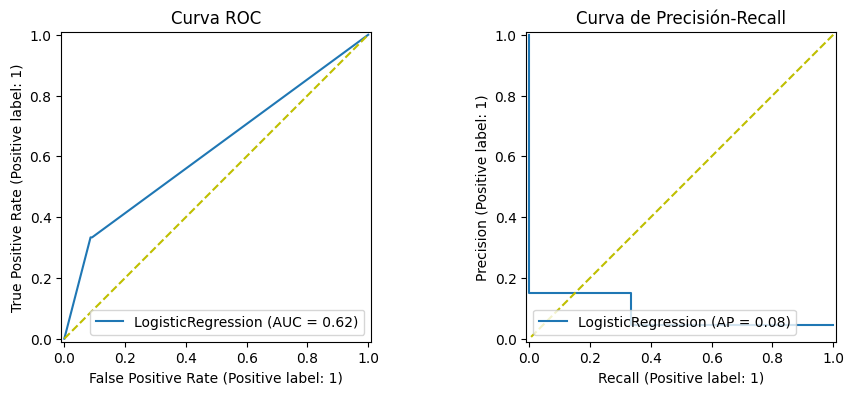

In [ ]:
# **+++++++++++ Inicia sección para agregar código ++++++++++++++++**
# NOTA: puedes agregar todas las celdas que consideres adecuado.



pipeline.fit(Xtest, np.ravel(ytest))


fig, axes = plt.subplots(1, 2, figsize=(10,15))
plt.subplots_adjust(wspace=0.5, hspace=0.5)
axes = axes.ravel()

# Curva ROC
RocCurveDisplay.from_estimator(mejor_modelo, X2, y2, ax=axes[0]) #acuérdate con el ax=axes[N] se le indica que ahí pones el gráfico
axes[0].plot([0, 1], [0, 1], 'y--')
axes[0].set_title('Curva ROC')

# Curva de Precisión-Recall
PrecisionRecallDisplay.from_estimator(mejor_modelo, X2, y2, ax=axes[1])
axes[1].plot([1,0], [1,0], 'y--')
axes[1].set_title('Curva de Precisión-Recall')

# Mostrar gráficos
plt.show()




# **+++++++++++ Termina sección para agregar código ++++++++++++++**

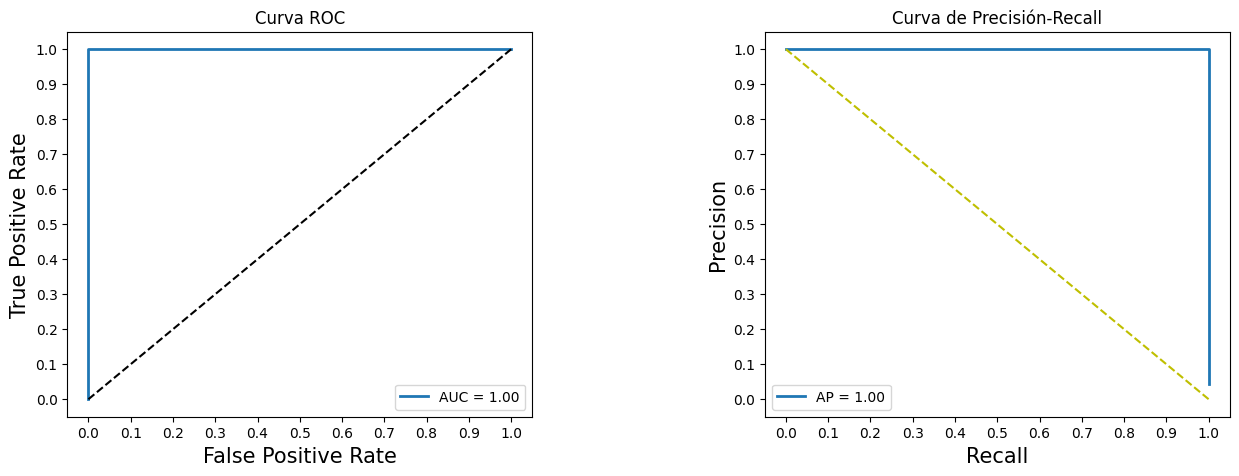

In [ ]:
pipeline.fit(Xtest, np.ravel(ytest)) # fit the pipeline to the training data
y_pred_proba = pipeline.predict_proba(Xtest)[:, 1] #get predicted probabilities for class 1

fig, axes = plt.subplots(1, 2, figsize=(15,5))
plt.subplots_adjust(wspace=0.5, hspace=0.5)
axes = axes.ravel()

# Curva ROC y AUC
FPR, TPR, _ = roc_curve(ytest, y_pred_proba)  # Usa las probabilidades predichas
roc_auc = roc_auc_score(ytest, y_pred_proba)
axes[0].plot(FPR, TPR, linewidth=2, label='AUC = {:.2f}'.format(roc_auc))
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlabel("False Positive Rate", fontsize=15)
axes[0].set_ylabel("True Positive Rate", fontsize=15)
axes[0].set_xticks(np.linspace(0, 1, 11))
axes[0].set_yticks(np.linspace(0, 1, 11))
axes[0].set_title('Curva ROC')
axes[0].legend(loc="lower right")

# Curva de Precisión-Recall y AUC (Average Precision)
precision, recall, _ = precision_recall_curve(ytest, y_pred_proba)
average_precision = average_precision_score(ytest, y_pred_proba)
axes[1].plot(recall, precision, linewidth=2, label='AP = {:.2f}'.format(average_precision))
axes[1].plot([0, 1], [1, 0], 'y--')
axes[1].set_xlabel("Recall", fontsize=15)
axes[1].set_ylabel("Precision", fontsize=15)
axes[1].set_xticks(np.linspace(0, 1, 11))
axes[1].set_yticks(np.linspace(0, 1, 11))
axes[1].set_title('Curva de Precisión-Recall')
axes[1].legend(loc="lower left")

# Mostrar gráficos
plt.show()

# **Ejercicio-6**

### **Incluye tus conclusiones finales de los resultados obtenidos y de la actividad en general.**

**+++++++++++ Inicia sección para agregar texto ++++++++++++++++**



Mis comentarios son muy similares a los del punto 5. Sólo que ahora arroja un modelo perfecto con el segundo código.




**+++++++++++ Termina sección para agregar texto ++++++++++++++**

## **<<< Fin de la Actividad de la Semana - curvas ROC y PR >>>**